In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import lightgbm as lgb
import joblib

warnings.filterwarnings("ignore")

In [2]:
#定位项目目录
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data").exists() and (
    (CURRENT_DIR / "notebook").exists() or (CURRENT_DIR / "notebooks").exists()
):
    PROJECT_DIR = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists() and (
    (CURRENT_DIR.parent / "notebook").exists() or (CURRENT_DIR.parent / "notebooks").exists()
):
    PROJECT_DIR = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Cannot locate project root. Please check your current working directory."
    )

DATA_RAW_DIR = PROJECT_DIR / "data" / "raw"

REPORT_DIR = PROJECT_DIR / "reports" / "model" / "lgbm_cv_tuning"
TABLE_DIR = REPORT_DIR / "tables"
FIGURE_DIR = REPORT_DIR / "figures"
SUBMISSION_DIR = PROJECT_DIR / "submissions"
MODEL_DIR = PROJECT_DIR / "models" / "lgbm_cv_tuning"

for path in [REPORT_DIR, TABLE_DIR, FIGURE_DIR, SUBMISSION_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_RAW_DIR)
print("Report directory:", REPORT_DIR)
print("Model directory:", MODEL_DIR)

Project directory: d:\A_projects\kaggle-star-type-prediction
Data directory: d:\A_projects\kaggle-star-type-prediction\data\raw
Report directory: d:\A_projects\kaggle-star-type-prediction\reports\model\lgbm_cv_tuning
Model directory: d:\A_projects\kaggle-star-type-prediction\models\lgbm_cv_tuning


In [3]:
#读取数据
train_path = DATA_RAW_DIR / "train.csv"
test_path = DATA_RAW_DIR / "test.csv"
sample_submission_path = DATA_RAW_DIR / "sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

display(train_df.head())
display(test_df.head())
display(sample_submission.head())

Train shape: (577347, 12)
Test shape: (247435, 11)
Sample submission shape: (247435, 2)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,GALAXY
4,577351,GALAXY


In [4]:
#构造颜色指数特征
def add_color_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add astronomical color index features.
    """
    df = df.copy()

    required_cols = ["u", "g", "r", "i", "z"]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"Missing columns for color features: {missing_cols}")

    df["u_g"] = df["u"] - df["g"]
    df["g_r"] = df["g"] - df["r"]
    df["r_i"] = df["r"] - df["i"]
    df["i_z"] = df["i"] - df["z"]

    return df


train_fe = add_color_features(train_df)
test_fe = add_color_features(test_df)

display(train_fe.head())
display(test_fe.head())

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,u_g,g_r,r_i,i_z
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY,3.576564,1.537632,1.100813,0.636056
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY,1.691447,1.499854,0.361141,0.439634
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO,-0.043925,-0.092712,0.589211,0.025263
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY,2.254320,2.032982,0.652096,0.450706
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY,2.231478,1.237231,0.335002,0.283262


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,u_g,g_r,r_i,i_z
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence,1.716387,0.865497,0.906151,0.977908
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence,2.564112,1.606658,0.871833,0.172640
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud,0.952958,0.923319,0.980640,0.393909
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence,1.594174,0.856696,0.252526,-0.281462
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence,2.450301,1.520808,1.683673,0.345342


In [5]:
#设置特征和标签
TARGET_COL = "class"
ID_COL = "id"

BASE_FEATURES = ["u", "g", "r", "i", "z", "redshift", "alpha", "delta"]
COLOR_FEATURES = ["u_g", "g_r", "r_i", "i_z"]

FEATURE_COLS = BASE_FEATURES + COLOR_FEATURES

missing_train_cols = [col for col in FEATURE_COLS if col not in train_fe.columns]
missing_test_cols = [col for col in FEATURE_COLS if col not in test_fe.columns]

if TARGET_COL not in train_fe.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in train.csv.")

if ID_COL not in test_fe.columns:
    raise ValueError(f"ID column '{ID_COL}' not found in test.csv.")

if missing_train_cols:
    raise ValueError(f"Missing feature columns in train data: {missing_train_cols}")

if missing_test_cols:
    raise ValueError(f"Missing feature columns in test data: {missing_test_cols}")

X = train_fe[FEATURE_COLS].copy()
y = train_fe[TARGET_COL].copy()
X_test = test_fe[FEATURE_COLS].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Feature columns:")
print(FEATURE_COLS)

print("\nClass mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i}: {cls}")

print("\nX shape:", X.shape)
print("X_test shape:", X_test.shape)

print("\nTarget distribution:")
display(y.value_counts())

Feature columns:
['u', 'g', 'r', 'i', 'z', 'redshift', 'alpha', 'delta', 'u_g', 'g_r', 'r_i', 'i_z']

Class mapping:
0: GALAXY
1: QSO
2: STAR

X shape: (577347, 12)
X_test shape: (247435, 12)

Target distribution:


class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

In [6]:
#设置交叉验证和调参范围
N_FOLDS = 5
RANDOM_STATE = 42

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

param_list = [
    {
        "name": "baseline_lr003_leaves31",
        "learning_rate": 0.03,
        "num_leaves": 31,
        "min_child_samples": 30,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "n_estimators": 3000,
    },
    {
        "name": "lr002_leaves31",
        "learning_rate": 0.02,
        "num_leaves": 31,
        "min_child_samples": 30,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "n_estimators": 4000,
    },
    {
        "name": "lr003_leaves63",
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_child_samples": 30,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "n_estimators": 3000,
    },
    {
        "name": "lr003_leaves63_more_regularized",
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_child_samples": 50,
        "reg_alpha": 0.5,
        "reg_lambda": 5.0,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "n_estimators": 3000,
    },
]

print("Number of parameter settings:", len(param_list))


Number of parameter settings: 4


In [7]:
#定义单组参数的CV函数
def run_lgbm_cv(params: dict, X: pd.DataFrame, y_encoded: np.ndarray) -> dict:
    """
    Run StratifiedKFold CV for one LightGBM parameter setting.
    """
    fold_metrics = []
    best_iterations = []

    oof_pred = np.zeros(len(X), dtype=int)
    oof_proba = np.zeros((len(X), len(label_encoder.classes_)), dtype=float)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_encoded), start=1):
        print(f"\n========== {params['name']} | Fold {fold}/{N_FOLDS} ==========")

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y_encoded[train_idx]
        y_val = y_encoded[val_idx]

        model = lgb.LGBMClassifier(
            objective="multiclass",
            num_class=len(label_encoder.classes_),
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            num_leaves=params["num_leaves"],
            max_depth=-1,
            min_child_samples=params["min_child_samples"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            random_state=RANDOM_STATE + fold,
            n_jobs=-1,
            force_col_wise=True,
            verbose=-1,
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="multi_logloss",
            callbacks=[
                lgb.early_stopping(stopping_rounds=150),
                lgb.log_evaluation(period=200),
            ],
        )

        val_proba = model.predict_proba(X_val)
        val_pred = np.argmax(val_proba, axis=1)

        oof_proba[val_idx] = val_proba
        oof_pred[val_idx] = val_pred

        fold_accuracy = accuracy_score(y_val, val_pred)
        fold_balanced_accuracy = balanced_accuracy_score(y_val, val_pred)
        fold_macro_f1 = f1_score(y_val, val_pred, average="macro")

        best_iter = model.best_iteration_ if model.best_iteration_ else params["n_estimators"]
        best_iterations.append(best_iter)

        fold_metrics.append(
            {
                "param_name": params["name"],
                "fold": fold,
                "accuracy": fold_accuracy,
                "balanced_accuracy": fold_balanced_accuracy,
                "macro_f1": fold_macro_f1,
                "best_iteration": best_iter,
            }
        )

        print(
            f"Fold {fold} | "
            f"Accuracy={fold_accuracy:.6f} | "
            f"Balanced Accuracy={fold_balanced_accuracy:.6f} | "
            f"Macro F1={fold_macro_f1:.6f} | "
            f"Best Iteration={best_iter}"
        )

    oof_accuracy = accuracy_score(y_encoded, oof_pred)
    oof_balanced_accuracy = balanced_accuracy_score(y_encoded, oof_pred)
    oof_macro_f1 = f1_score(y_encoded, oof_pred, average="macro")

    result = {
        "param_name": params["name"],
        "params": params,
        "fold_metrics": fold_metrics,
        "oof_accuracy": oof_accuracy,
        "oof_balanced_accuracy": oof_balanced_accuracy,
        "oof_macro_f1": oof_macro_f1,
        "mean_best_iteration": int(np.mean(best_iterations)),
        "oof_pred": oof_pred,
        "oof_proba": oof_proba,
    }

    print(f"\n===== OOF Result: {params['name']} =====")
    print(f"OOF Accuracy: {oof_accuracy:.6f}")
    print(f"OOF Balanced Accuracy: {oof_balanced_accuracy:.6f}")
    print(f"OOF Macro F1: {oof_macro_f1:.6f}")
    print(f"Mean Best Iteration: {result['mean_best_iteration']}")

    return result

In [8]:
#开始调参
all_results = []

for params in param_list:
    result = run_lgbm_cv(params, X, y_encoded)
    all_results.append(result)

summary_df = pd.DataFrame(
    [
        {
            "param_name": result["param_name"],
            "oof_accuracy": result["oof_accuracy"],
            "oof_balanced_accuracy": result["oof_balanced_accuracy"],
            "oof_macro_f1": result["oof_macro_f1"],
            "mean_best_iteration": result["mean_best_iteration"],
        }
        for result in all_results
    ]
).sort_values("oof_macro_f1", ascending=False)

display(summary_df)

summary_path = TABLE_DIR / "lgbm_cv_tuning_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("CV tuning summary saved to:", summary_path)


========== baseline_lr003_leaves31 | Fold 1/5 ==========
Training until validation scores don't improve for 150 rounds
[200]	valid_0's multi_logloss: 0.102591
[400]	valid_0's multi_logloss: 0.0947099
[600]	valid_0's multi_logloss: 0.0921311
[800]	valid_0's multi_logloss: 0.0908756
[1000]	valid_0's multi_logloss: 0.0899648
[1200]	valid_0's multi_logloss: 0.0893474
[1400]	valid_0's multi_logloss: 0.0888896
[1600]	valid_0's multi_logloss: 0.0885949
[1800]	valid_0's multi_logloss: 0.088415
[2000]	valid_0's multi_logloss: 0.0883501
[2200]	valid_0's multi_logloss: 0.0883389
Early stopping, best iteration is:
[2079]	valid_0's multi_logloss: 0.0883222
Fold 1 | Accuracy=0.968104 | Balanced Accuracy=0.955684 | Macro F1=0.957066 | Best Iteration=2079

========== baseline_lr003_leaves31 | Fold 2/5 ==========
Training until validation scores don't improve for 150 rounds
[200]	valid_0's multi_logloss: 0.103068
[400]	valid_0's multi_logloss: 0.0950076
[600]	valid_0's multi_logloss: 0.092671
[800]	va

,param_name,oof_accuracy,oof_balanced_accuracy,oof_macro_f1,mean_best_iteration
2,lr003_leaves63,0.968234,0.956756,0.957276,1259
3,lr003_leaves63_more_regularized,0.968142,0.956625,0.957168,1308
0,baseline_lr003_leaves31,0.968045,0.956528,0.957039,2174
1,lr002_leaves31,0.968052,0.956525,0.957017,3393


CV tuning summary saved to: d:\A_projects\kaggle-star-type-prediction\reports\model\lgbm_cv_tuning\tables\lgbm_cv_tuning_summary.csv


In [9]:
#保存每折结果
fold_metrics_df = pd.DataFrame(
    [
        metric
        for result in all_results
        for metric in result["fold_metrics"]
    ]
)

display(fold_metrics_df)

fold_metrics_path = TABLE_DIR / "lgbm_cv_fold_metrics.csv"
fold_metrics_df.to_csv(fold_metrics_path, index=False)

print("Fold metrics saved to:", fold_metrics_path)

,param_name,fold,accuracy,balanced_accuracy,macro_f1,best_iteration
0,baseline_lr003_leaves31,1,0.968104,0.955684,0.957066,2079
1,baseline_lr003_leaves31,2,0.968529,0.957628,0.957667,2227
2,baseline_lr003_leaves31,3,0.967229,0.955990,0.955922,2104
3,baseline_lr003_leaves31,4,0.968520,0.956505,0.957635,2423
4,baseline_lr003_leaves31,5,0.967844,0.956834,0.956907,2039
5,lr002_leaves31,1,0.968338,0.955893,0.957390,3501
6,lr002_leaves31,2,0.968607,0.957792,0.957795,3378
7,lr002_leaves31,3,0.967463,0.956284,0.956210,3842
8,lr002_leaves31,4,0.968225,0.956211,0.957188,3402
9,lr002_leaves31,5,0.967628,0.956446,0.956505,2842


Fold metrics saved to: d:\A_projects\kaggle-star-type-prediction\reports\model\lgbm_cv_tuning\tables\lgbm_cv_fold_metrics.csv


In [10]:
#选择最佳参数
best_result = max(all_results, key=lambda x: x["oof_macro_f1"])
best_params = best_result["params"]

print("Best parameter setting:", best_result["param_name"])
print("Best OOF Accuracy:", best_result["oof_accuracy"])
print("Best OOF Balanced Accuracy:", best_result["oof_balanced_accuracy"])
print("Best OOF Macro F1:", best_result["oof_macro_f1"])
print("Mean Best Iteration:", best_result["mean_best_iteration"])

best_params_path = TABLE_DIR / "best_lgbm_params.json"

with open(best_params_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=4)

print("Best parameters saved to:", best_params_path)

Best parameter setting: lr003_leaves63
Best OOF Accuracy: 0.9682340083173551
Best OOF Balanced Accuracy: 0.9567559114836309
Best OOF Macro F1: 0.9572760610248653
Mean Best Iteration: 1259
Best parameters saved to: d:\A_projects\kaggle-star-type-prediction\reports\model\lgbm_cv_tuning\tables\best_lgbm_params.json


In [11]:
#最佳参数的分类报告
best_oof_pred = best_result["oof_pred"]

report_dict = classification_report(
    y_encoded,
    best_oof_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).T
display(report_df)

report_path = TABLE_DIR / "lgbm_cv_classification_report.csv"
report_df.to_csv(report_path, index=True)

print("Classification report saved to:", report_path)

,precision,recall,f1-score,support
GALAXY,0.977114,0.978264,0.977689,377480.000000
QSO,0.967076,0.965102,0.966088,117143.000000
STAR,0.929204,0.926902,0.928051,82724.000000
accuracy,0.968234,0.968234,0.968234,0.968234
macro avg,0.957798,0.956756,0.957276,577347.000000
weighted avg,0.968213,0.968234,0.968223,577347.000000


Classification report saved to: d:\A_projects\kaggle-star-type-prediction\reports\model\lgbm_cv_tuning\tables\lgbm_cv_classification_report.csv


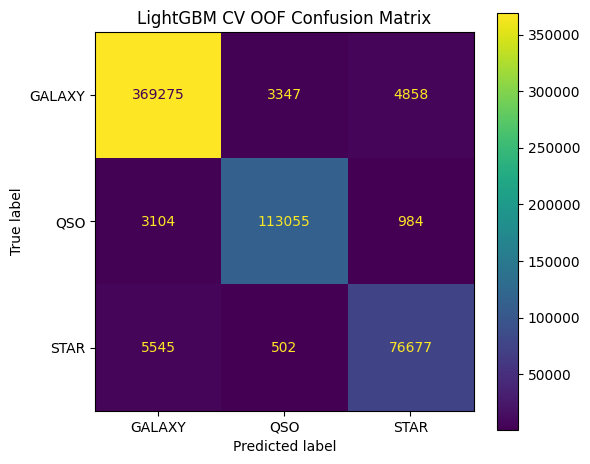

Confusion matrix saved to: d:\A_projects\kaggle-star-type-prediction\reports\model\lgbm_cv_tuning\figures\lgbm_cv_oof_confusion_matrix.png


In [12]:
#最佳参数的混淆矩阵
cm = confusion_matrix(y_encoded, best_oof_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_,
)
disp.plot(ax=ax, values_format="d")
ax.set_title("LightGBM CV OOF Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = FIGURE_DIR / "lgbm_cv_oof_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", confusion_matrix_path)

In [13]:
#用最佳参数重新训练5折模型并预测test
test_proba_sum = np.zeros((len(X_test), len(label_encoder.classes_)), dtype=float)
fold_models = []
fold_feature_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_encoded), start=1):
    print(f"\n========== Final CV Training | Fold {fold}/{N_FOLDS} ==========")

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y_encoded[train_idx]
    y_val = y_encoded[val_idx]

    final_model = lgb.LGBMClassifier(
        objective="multiclass",
        num_class=len(label_encoder.classes_),
        n_estimators=best_params["n_estimators"],
        learning_rate=best_params["learning_rate"],
        num_leaves=best_params["num_leaves"],
        max_depth=-1,
        min_child_samples=best_params["min_child_samples"],
        subsample=best_params["subsample"],
        colsample_bytree=best_params["colsample_bytree"],
        reg_alpha=best_params["reg_alpha"],
        reg_lambda=best_params["reg_lambda"],
        random_state=RANDOM_STATE + 100 + fold,
        n_jobs=-1,
        force_col_wise=True,
        verbose=-1,
    )

    final_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
        callbacks=[
            lgb.early_stopping(stopping_rounds=150),
            lgb.log_evaluation(period=200),
        ],
    )

    fold_test_proba = final_model.predict_proba(X_test)
    test_proba_sum += fold_test_proba / N_FOLDS

    fold_models.append(final_model)

    fold_importance_df = pd.DataFrame(
        {
            "feature": FEATURE_COLS,
            "importance": final_model.feature_importances_,
            "fold": fold,
        }
    )
    fold_feature_importances.append(fold_importance_df)

    model_path = MODEL_DIR / f"lgbm_cv_tuned_fold_{fold}.pkl"
    joblib.dump(final_model, model_path)

    print("Saved fold model to:", model_path)

label_encoder_path = MODEL_DIR / "label_encoder.pkl"
joblib.dump(label_encoder, label_encoder_path)

print("Saved label encoder to:", label_encoder_path)


========== Final CV Training | Fold 1/5 ==========
Training until validation scores don't improve for 150 rounds
[200]	valid_0's multi_logloss: 0.0967013
[400]	valid_0's multi_logloss: 0.0908201
[600]	valid_0's multi_logloss: 0.0890239
[800]	valid_0's multi_logloss: 0.0882082
[1000]	valid_0's multi_logloss: 0.0878648
[1200]	valid_0's multi_logloss: 0.0876685
Early stopping, best iteration is:
[1176]	valid_0's multi_logloss: 0.0876524
Saved fold model to: d:\A_projects\kaggle-star-type-prediction\models\lgbm_cv_tuning\lgbm_cv_tuned_fold_1.pkl

========== Final CV Training | Fold 2/5 ==========
Training until validation scores don't improve for 150 rounds
[200]	valid_0's multi_logloss: 0.0972198
[400]	valid_0's multi_logloss: 0.0912712
[600]	valid_0's multi_logloss: 0.089816
[800]	valid_0's multi_logloss: 0.0892188
[1000]	valid_0's multi_logloss: 0.0889584
[1200]	valid_0's multi_logloss: 0.0889275
Early stopping, best iteration is:
[1077]	valid_0's multi_logloss: 0.0888902
Saved fold mo

In [14]:
#生成提交文件
test_pred_encoded = np.argmax(test_proba_sum, axis=1)
test_pred = label_encoder.inverse_transform(test_pred_encoded)

submission_df = sample_submission.copy()

if TARGET_COL in submission_df.columns:
    submission_df[TARGET_COL] = test_pred
else:
    pred_col = submission_df.columns[1]
    submission_df[pred_col] = test_pred
    print(f"Prediction column is '{pred_col}', not '{TARGET_COL}'.")

display(submission_df.head())

print("Prediction distribution:")
display(submission_df[TARGET_COL].value_counts())
display(submission_df[TARGET_COL].value_counts(normalize=True))

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


Prediction distribution:


class
GALAXY    162084
QSO        50061
STAR       35290
Name: count, dtype: int64

class
GALAXY    0.655057
QSO       0.202320
STAR      0.142623
Name: proportion, dtype: float64

In [15]:
#保存提交文件
submission_path = SUBMISSION_DIR / "lgbm_cv_tuned_submission.csv"

submission_df.to_csv(submission_path, index=False)

print("Submission file saved to:")
print(submission_path)

Submission file saved to:
d:\A_projects\kaggle-star-type-prediction\submissions\lgbm_cv_tuned_submission.csv


In [16]:
#检查提交文件格式
check_submission = pd.read_csv(submission_path)

print("Submission shape:", check_submission.shape)
display(check_submission.head())

print("Missing values:")
display(check_submission.isna().sum())

print("Columns:")
print(check_submission.columns.tolist())

print("Prediction distribution:")
display(check_submission[TARGET_COL].value_counts())
display(check_submission[TARGET_COL].value_counts(normalize=True))

Submission shape: (247435, 2)


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


Missing values:


id       0
class    0
dtype: int64

Columns:
['id', 'class']
Prediction distribution:


class
GALAXY    162084
QSO        50061
STAR       35290
Name: count, dtype: int64

class
GALAXY    0.655057
QSO       0.202320
STAR      0.142623
Name: proportion, dtype: float64

,feature,mean_importance,std_importance
0,alpha,31583.4,2682.151338
1,delta,30931.4,2698.626002
8,redshift,24310.2,2543.990507
7,r_i,19226.8,2293.004078
3,g_r,18712.0,2418.300953
5,i_z,18607.0,2281.369874
10,u_g,18166.8,2239.639190
11,z,16620.8,1731.302169
9,u,16331.6,1888.423099
2,g,14636.0,1728.539702


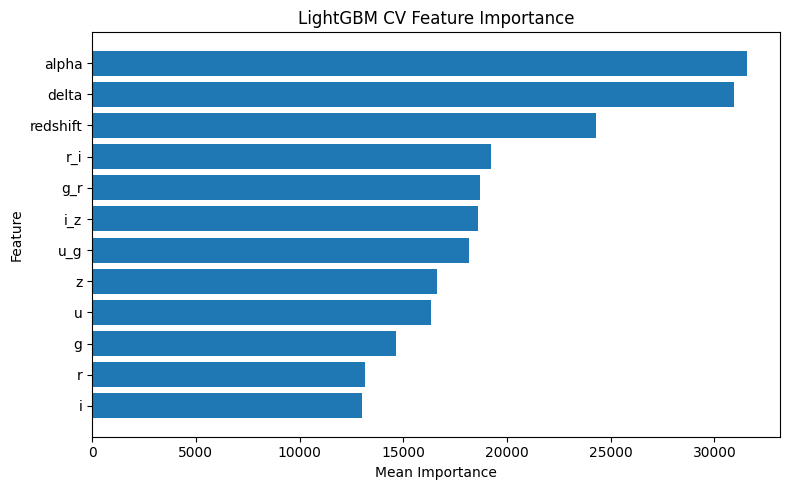

Feature importance table saved to: d:\A_projects\kaggle-star-type-prediction\reports\model\lgbm_cv_tuning\tables\lgbm_cv_feature_importance.csv
Feature importance figure saved to: d:\A_projects\kaggle-star-type-prediction\reports\model\lgbm_cv_tuning\figures\lgbm_cv_feature_importance.png


In [17]:
#保存特征重要性
feature_importance_df = pd.concat(fold_feature_importances, axis=0)

feature_importance_summary = (
    feature_importance_df
    .groupby("feature", as_index=False)
    .agg(
        mean_importance=("importance", "mean"),
        std_importance=("importance", "std"),
    )
    .sort_values("mean_importance", ascending=False)
)

display(feature_importance_summary)

feature_importance_path = TABLE_DIR / "lgbm_cv_feature_importance.csv"
feature_importance_summary.to_csv(feature_importance_path, index=False)

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance_summary["feature"].iloc[::-1],
    feature_importance_summary["mean_importance"].iloc[::-1],
)
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.title("LightGBM CV Feature Importance")
plt.tight_layout()

feature_importance_fig_path = FIGURE_DIR / "lgbm_cv_feature_importance.png"
plt.savefig(feature_importance_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Feature importance table saved to:", feature_importance_path)
print("Feature importance figure saved to:", feature_importance_fig_path)

In [19]:
#生成报告
best_public_score_note = "待Kaggle提交后填写"

best_params_text = json.dumps(best_params, indent=4, ensure_ascii=False)

report_md = f"""
# LightGBM CV Tuning Report

## Objective

This notebook performs cross-validation and small-range hyperparameter tuning for the LightGBM model with color index features.

## Feature Set

Base features:

{BASE_FEATURES}

Color index features:

{COLOR_FEATURES}

Final feature set:

{FEATURE_COLS}

## Cross-Validation Setting

- Validation method: {N_FOLDS}-fold StratifiedKFold
- Selection metric: OOF Macro F1
- Random state: {RANDOM_STATE}

## Tuning Summary

The tuning summary is saved in:

`reports/model/lgbm_cv_tuning/tables/lgbm_cv_tuning_summary.csv`

## Best Parameter Setting

Best parameter name:

`{best_result["param_name"]}`

Best parameters:

{best_params_text}

## Best OOF Results

| Model | OOF Accuracy | OOF Balanced Accuracy | OOF Macro F1 | Mean Best Iteration |
|---|---:|---:|---:|---:|
| LightGBM CV Tuned | {best_result["oof_accuracy"]:.6f} | {best_result["oof_balanced_accuracy"]:.6f} | {best_result["oof_macro_f1"]:.6f} | {best_result["mean_best_iteration"]} |

## Submission File

The generated submission file is:

`submissions/lgbm_cv_tuned_submission.csv`

Kaggle Public Score:

{best_public_score_note}

## Comparison with Previous Models

| Model | Validation/CV Metric | Kaggle Public Score |
|---|---:|---:|
| RandomForest + color features | 0.944721 | 0.94506 |
| LightGBM + color features | 0.956350 | 0.95719 |
| LightGBM CV tuned | {best_result["oof_macro_f1"]:.6f} | 待提交后填写 |

## Conclusion

The best cross-validation parameter setting is `{best_result["param_name"]}`.
It achieved an OOF Macro F1 of {best_result["oof_macro_f1"]:.6f}, which is slightly higher than the previous single-split LightGBM validation result.
The generated submission file should be submitted to Kaggle and compared with the current best public score of 0.95719.
"""

report_path = REPORT_DIR / "lgbm_cv_tuning_report.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_md)

print("Report saved to:", report_path)

Report saved to: d:\A_projects\kaggle-star-type-prediction\reports\model\lgbm_cv_tuning\lgbm_cv_tuning_report.md
